# 0. Importing Necessary Libraries


In [1]:
from umap import UMAP # for UMAP latent space projections
import sys # for relatove imports of sigma

In [2]:
%matplotlib ipympl
# interactive matplotlib backend, for inline plotting in jupyter notebooks

Using relative imports for sigma and its packages whilst they are being redeveloped

In [3]:
sys.path.insert(0,"..")

import sigma
from sigma.utils import normalisation as norm 
from sigma.utils import visualisation as visual
from sigma.utils.load import SEMDataset
from sigma.src.utils import same_seeds
from sigma.src.dim_reduction import Experiment
from sigma.models.autoencoder import AutoEncoder
from sigma.src.segmentation import PixelSegmenter
from sigma.gui import gui
from sigma.utils.loadtem import TEMDataset


# 1. Loading and Pre-Processing a hdf5 dataset

The dataset used for this tutorial is a STEM-EDX dataset studying FePt@Fe$_3$O$_4$ core shell nanoparticles.

The sample and the data used are described in D. Roussow, et al., Nano Letters, In Press (2015) (see the [full article](https://www.repository.cam.ac.uk/bitstreams/087de702-2cc8-4c30-94f9-a6ac02af996c/download) ).

## 1.1 Loading the data

In [4]:
file_path='core_shell.hdf5'
tem=TEMDataset(file_path)

## 1.2 The `TEMDataset` object

The `TEMDataset` object can thought of as a hyperspy `Signal` object, in this case an `EDSTEMSpectrum` object, with added methods. The underlying hyperspy signal can be acessed with the `base_dataset` attribute

In [5]:
tem.base_dataset

<EDSTEMSpectrum, title: Core shell, dimensions: (32, 32|992)>

## 1.3 Visualisation of the raw data

Before preprocessing, the dataset can be visualised with using the SIGMA gui

In [6]:
gui.view_dataset(tem)

Output()

Output()

## 1.4 Pre-processing the dataset before projecting and segmenting

The processing steps involve
1. Rebinning the signal in the navigation dimension.
2. Removing the first peak at 0 eV, by cropping the signal up to the desired energy
3. Normalising the peak intensity, such that for each pixel in the navigation image, the integrated intensity of the EDX spectrum is 1

In [7]:
tem.rebin_signal(size=(1,1)) # works

tem.remove_fist_peak(end=0.4) #works

tem.peak_intensity_normalisation() #works (see binned maps)

Rebinning the intensity with the size of (1, 1)
Removing the fisrt peak by setting the intensity to zero until the energy of 0.4 keV.
Normalising the chemical intensity along axis=2, so that the sum is equal to 1 along axis=2.


<EDSTEMSpectrum, title: Core shell, dimensions: (32, 32|992)>

These pre-processing methods have relevant doctrings, which can be accessed either by running (for example):

`tem.rebin_signal?`

Or, interactively by pressing <kbd>Shift</kbd> + <kbd>Tab</kbd> whilst editing the cell with the brackets open of the method.

In [8]:
tem.rebin_signal?

Signature: tem.rebin_signal(size=(2, 2))
Docstring:
Rebins the navigation axes of the hyperspectral image and navigation image (eg. a BSE image) contained in BaseDataSet.



Parameters
----------
size : Tuple
    A 2 element tuple of the form (x_bin,y_bin) where x_bin and y_bin define the number of pixels to sum in the x and y axis respectively
    into a single, summed pixel in the binned signal.

Returns
----------
(spectra_bin,nav_img_bin) : Tuple
    The binned signals of the hyperspectral image and the navigation image
    
File:      c:\users\tom\documents\postdoc\sigma2\sigma2\sigma\utils\base.py
Type:      method

![Screenshot demonstrating the interactive shift+tab functionality](shift_tab_helper.png)

## 1.5  Viewing the pre_processed data and adding elements
The signal can be viewed the same way after pre-processing

Based on the summed spectra, one can identify X-Ray peaks which are also present in the signal using the functionality within the gui.

Then type the full list of elements into the feature list widget to add them

In [9]:
gui.view_dataset(tem)

Output()

Output()


The intensity for each elemental map is the integrated intensity of the peak, without background subtraction, integrated across the 2 x FWHM of the peak.

The intensities data can be accessed with the `get_lines_intensity` method from the `hyperspy._sigmals.eds` module

## 1.6 Data Processing and Normalisation

The data is processed sequentially with three steps, more details can be found [here](https://doi.org/10.1029/2022GC010530)

1. Neighbour Averaging - Replaces the intensity at each pixel with a the averaged value of the neighbouring grid, (default 3x3 grid)
2. zscore normalisation - Scales the distribution of pixel intensiites such that the mean is 0 and standard deviation is one
3. Applies the softmax function to the intensity distribution, which applies the exponential function to the intenisty at each pixel and normalises the distribution. The effects of this is that any maxima in the signal space are amplified. [More details on softmax function](https://en.wikipedia.org/wiki/Softmax_function)


Each of these methods has docstrings for quick referencing with <kbd>Shift</kbd>+<kbd>Tab</kbd> 
   


In [10]:
tem.normalisation([norm.neighbour_averaging, 
                   norm.zscore,
                   norm.softmax])

Set feature_list to ['Fe_Ka', 'Pt_La']
Normalise dataset using:
    1. neighbour_averaging
    2. zscore
    3. softmax


## 1.7 Visualising effects of normalisation

The new pixel distributions can be visualised using the `view_pixel_distributions` function

In [11]:
gui.view_pixel_distributions(dataset=tem, 
                             norm_list=[norm.neighbour_averaging,
                                        norm.zscore,
                                        norm.softmax], 
                             cmap='Reds')

## 1.8 Viewing the dataset as RGB signals

For initial inspection of elemental distributions, the dataset can be visualised using the `view_rgb` function

In [12]:
gui.view_rgb(dataset=tem)

Output()

## Testing the Dimensionality Reduction algorithms

# 1. UMAP

In [13]:
data = tem.normalised_elemental_data.reshape(-1,len(tem.feature_list)) 

In [14]:
umap = UMAP(
        n_neighbors=20,
        min_dist=0.1,
        n_components=2,
        metric='euclidean'
    )
latent_umap = umap.fit_transform(data)

NameError: name 'latent' is not defined

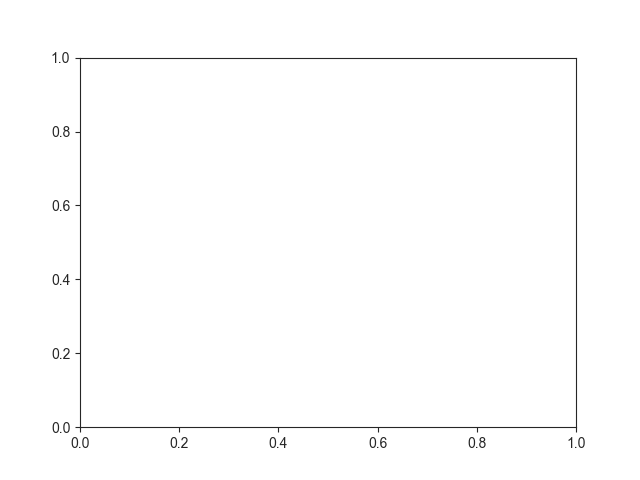

In [15]:
import matplotlib.pyplot as plt
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(latent_umap[:,0], latent[:,1])


Looks like UMAP is working

### testing the autoencoder

In [ ]:
same_seeds(2)

# set the folder path to save the model(the model will automatically save in the specified folder)
result_folder_path='./' 

# Set up the experiment, e.g. determining the model structure, dataset for training etc.
ex = Experiment(descriptor='softmax',
                general_results_dir=result_folder_path,
                model=AutoEncoder,
                model_args={'hidden_layer_sizes':(8,4,2)}, 
                chosen_dataset=tem.normalised_elemental_data,
                save_model_every_epoch=False)

In [ ]:
ex.run_model(num_epochs=50,
             batch_size=32,
             learning_rate=1e-4, 
             weight_decay=0.0, 
             task='train_all', 
             criterion='MSE'
            ) 
latent = ex.get_latent()

seems to be running ok

# Testing pixel segmentation

In [ ]:
gui.view_bic(latent=latent_umap,
             model='GaussianMixture',
             n_components=40,
             model_args={'random_state':6, 'init_params':'kmeans'})

In [17]:
ps = PixelSegmenter(latent=latent_umap, 
                    dataset=tem,
                    method="GaussianMixture",
                    method_args={'n_components':4, 'random_state':6, 'init_params':'kmeans'} )

In [116]:
gui.view_latent_space(ps=ps, color=True) 

In [18]:
gui.check_latent_space(ps=ps,show_map=True) # need to figure out better way to scale the image here

alt.HConcatChart(...)

In [123]:
gui.show_cluster_distribution(ps=ps) #not segmenting nicely

SelectMultiple(options=('All', 'cluster_0', 'cluster_1', 'cluster_2', 'cluster_3'), value=())

Output()

Output()

In [ ]:
len(